# Topic 12.4 — Mughal Architecture Identifier (Tier 1)

**Team Members:**
- Mohammed Sami - 2025121005
- Shreyash Chandak - 2025121006

---

### Problem Statement
A tourist points their phone at a Mughal monument — the app identifies it, shows its history, visit info, and a Google Maps link.

### Approach
- **Base model:** OpenAI CLIP ViT-B/32 (zero-shot, 15 classes)
- **Fine-tuned specialist:** Partial fine-tuning of vision blocks 9–11 + projection head on 13 confusable classes
- **Training objective:** Image-to-class-prompt cross-entropy with label smoothing (0.1)
- **Dataset:** Custom-curated collection of 15 Mughal monuments (796 real images + 244 offline augmentations). We manually gathered these images to create a balanced, challenging dataset for fine-grained architecture classification.
- **Deployment:** Streamlit app with hybrid inference (base zero-shot → specialist fallback)


In [3]:
!pip install -q -r /content/requirements.txt

In [4]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
Tesla T4


In [5]:
import zipfile

with zipfile.ZipFile("/content/data.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [6]:
import os
print(os.listdir("/content/data")[:10])

['Qutub Minar', 'Jama Masjid Delhi', 'Red Fort', 'Itmad-ud-Daulah', 'Buland Darwaza', "Humayun's Tomb", 'Fatehpur Sikri', 'Safdarjung Tomb', "Akbar's Tomb", 'Tomb of Salim Chishti']


In [11]:
# ── Cell A: Dataset audit ────────────────────────────────────────────────────
import os, unicodedata

DATA_DIR = "/content/data"

# Count images per folder and print raw repr of the folder name
valid_suffixes = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
print(f"{'Folder name (repr)':<55} {'count':>6}")
print("-" * 65)
total = 0
for cls in sorted(os.listdir(DATA_DIR)):
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    imgs = [
        f for f in os.listdir(cls_dir)
        if os.path.splitext(f)[1].lower() in valid_suffixes
    ]
    flag = ""
    # Check every character for non-ASCII (catches curly apostrophe U+2019)
    for ch in cls:
        if ord(ch) > 127:
            flag = f"  ⚠️  NON-ASCII: U+{ord(ch):04X} ({unicodedata.name(ch, '?')})"
            break
    print(f"{repr(cls):<55} {len(imgs):>6}{flag}")
    total += len(imgs)
print("-" * 65)
print(f"Total images: {total}")


Folder name (repr)                                       count
-----------------------------------------------------------------
'Agra Fort'                                                 79
"Akbar's Tomb"                                              36
'Bibi Ka Maqbara'                                           62
'Buland Darwaza'                                            56
'Fatehpur Sikri'                                            42
"Humayun's Tomb"                                           166
'Itmad-ud-Daulah'                                           77
'Jama Masjid Delhi'                                         54
'Moti Masjid Agra'                                          62
'Qutub Minar'                                               48
'Red Fort'                                                  59
'Safdarjung Tomb'                                           66
'Shalimar Bagh'                                             49
'Taj Mahal'                                         

In [12]:
# ── Cell B: Apostrophe fix + offline augmentation ────────────────────────────
import os, shutil, random
from PIL import Image, ImageEnhance, ImageFilter, ImageOps
import torchvision.transforms as T
import torchvision.transforms.functional as TF

DATA_DIR   = "/content/data"
TARGET     = 80       # augment up to this many images per class
SEED       = 42
valid_suffixes = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

random.seed(SEED)

# ── Step 1: Fix curly apostrophe folder names ─────────────────────────────────
print("=== Step 1: Apostrophe normalisation ===")
for cls in sorted(os.listdir(DATA_DIR)):
    fixed = cls.replace("\u2019", "'")   # RIGHT SINGLE QUOTATION MARK → straight
    if fixed != cls:
        src = os.path.join(DATA_DIR, cls)
        dst = os.path.join(DATA_DIR, fixed)
        print(f"  Renaming: {repr(cls)} → {repr(fixed)}")
        shutil.move(src, dst)
print("  Done.")

# ── Step 2: Offline augmentation ──────────────────────────────────────────────
augment = T.Compose([
    T.RandomResizedCrop(224, scale=(0.65, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.04),
    T.RandomPerspective(distortion_scale=0.15, p=0.4),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    T.Resize((256, 256)),  # save at consistent size
])

print("\n=== Step 2: Offline augmentation (target per class: %d) ===" % TARGET)
for cls in sorted(os.listdir(DATA_DIR)):
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue

    # Collect real images (skip already-augmented copies named aug_*)
    real_imgs = [
        f for f in sorted(os.listdir(cls_dir))
        if os.path.splitext(f)[1].lower() in valid_suffixes
        and not f.startswith("aug_")
    ]
    count = len(real_imgs)

    if count == 0:
        print(f"  SKIP {cls!r}: no images found")
        continue
    if count >= TARGET:
        print(f"  OK   {cls!r}: {count} images (already >= {TARGET})")
        continue

    needed = TARGET - count
    print(f"  AUG  {cls!r}: {count} images → generating {needed} more", end="", flush=True)

    aug_idx = 0
    while aug_idx < needed:
        src_name = random.choice(real_imgs)
        src_path = os.path.join(cls_dir, src_name)
        try:
            img = Image.open(src_path).convert("RGB")
        except Exception:
            continue

        aug_img = augment(img)
        dst_name = f"aug_{aug_idx:04d}.jpg"
        dst_path = os.path.join(cls_dir, dst_name)
        aug_img.save(dst_path, "JPEG", quality=92)
        aug_idx += 1

    print(f"  ✓ now {TARGET} images")

print("\nAugmentation complete.")


=== Step 1: Apostrophe normalisation ===
  Done.

=== Step 2: Offline augmentation (target per class: 80) ===
  AUG  'Agra Fort': 79 images → generating 1 more  ✓ now 80 images
  AUG  "Akbar's Tomb": 36 images → generating 44 more  ✓ now 80 images
  AUG  'Bibi Ka Maqbara': 62 images → generating 18 more  ✓ now 80 images
  AUG  'Buland Darwaza': 56 images → generating 24 more  ✓ now 80 images
  AUG  'Fatehpur Sikri': 42 images → generating 38 more  ✓ now 80 images
  OK   "Humayun's Tomb": 166 images (already >= 80)
  AUG  'Itmad-ud-Daulah': 77 images → generating 3 more  ✓ now 80 images
  AUG  'Jama Masjid Delhi': 54 images → generating 26 more  ✓ now 80 images
  AUG  'Moti Masjid Agra': 62 images → generating 18 more  ✓ now 80 images
  AUG  'Qutub Minar': 48 images → generating 32 more  ✓ now 80 images
  AUG  'Red Fort': 59 images → generating 21 more  ✓ now 80 images
  AUG  'Safdarjung Tomb': 66 images → generating 14 more  ✓ now 80 images
  AUG  'Shalimar Bagh': 49 images → generatin

In [13]:
# ── Cell C: Post-augmentation audit ──────────────────────────────────────────
import os

DATA_DIR = "/content/data"
valid_suffixes = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

print(f"{'Class':<35} {'real':>6} {'aug':>6} {'total':>6}")
print("-" * 57)
for cls in sorted(os.listdir(DATA_DIR)):
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    all_files = [f for f in os.listdir(cls_dir) if os.path.splitext(f)[1].lower() in valid_suffixes]
    real = [f for f in all_files if not f.startswith("aug_")]
    aug  = [f for f in all_files if f.startswith("aug_")]
    print(f"{cls:<35} {len(real):>6} {len(aug):>6} {len(all_files):>6}")


Class                                 real    aug  total
---------------------------------------------------------
Agra Fort                               79      1     80
Akbar's Tomb                            36     44     80
Bibi Ka Maqbara                         62     18     80
Buland Darwaza                          56     24     80
Fatehpur Sikri                          42     38     80
Humayun's Tomb                         166      0    166
Itmad-ud-Daulah                         77      3     80
Jama Masjid Delhi                       54     26     80
Moti Masjid Agra                        62     18     80
Qutub Minar                             48     32     80
Red Fort                                59     21     80
Safdarjung Tomb                         66     14     80
Shalimar Bagh                           49     31     80
Taj Mahal                              187      0    187
Tomb of Salim Chishti                   43     37     80


## Custom Curated Dataset
We curated our own dataset of 15 Mughal monuments because distinguishing between visually similar architectures (like Taj Mahal vs. Bibi Ka Maqbara, or Red Fort vs. Agra Fort) requires specialized, high-quality images. Below are a few random samples from our dataset.

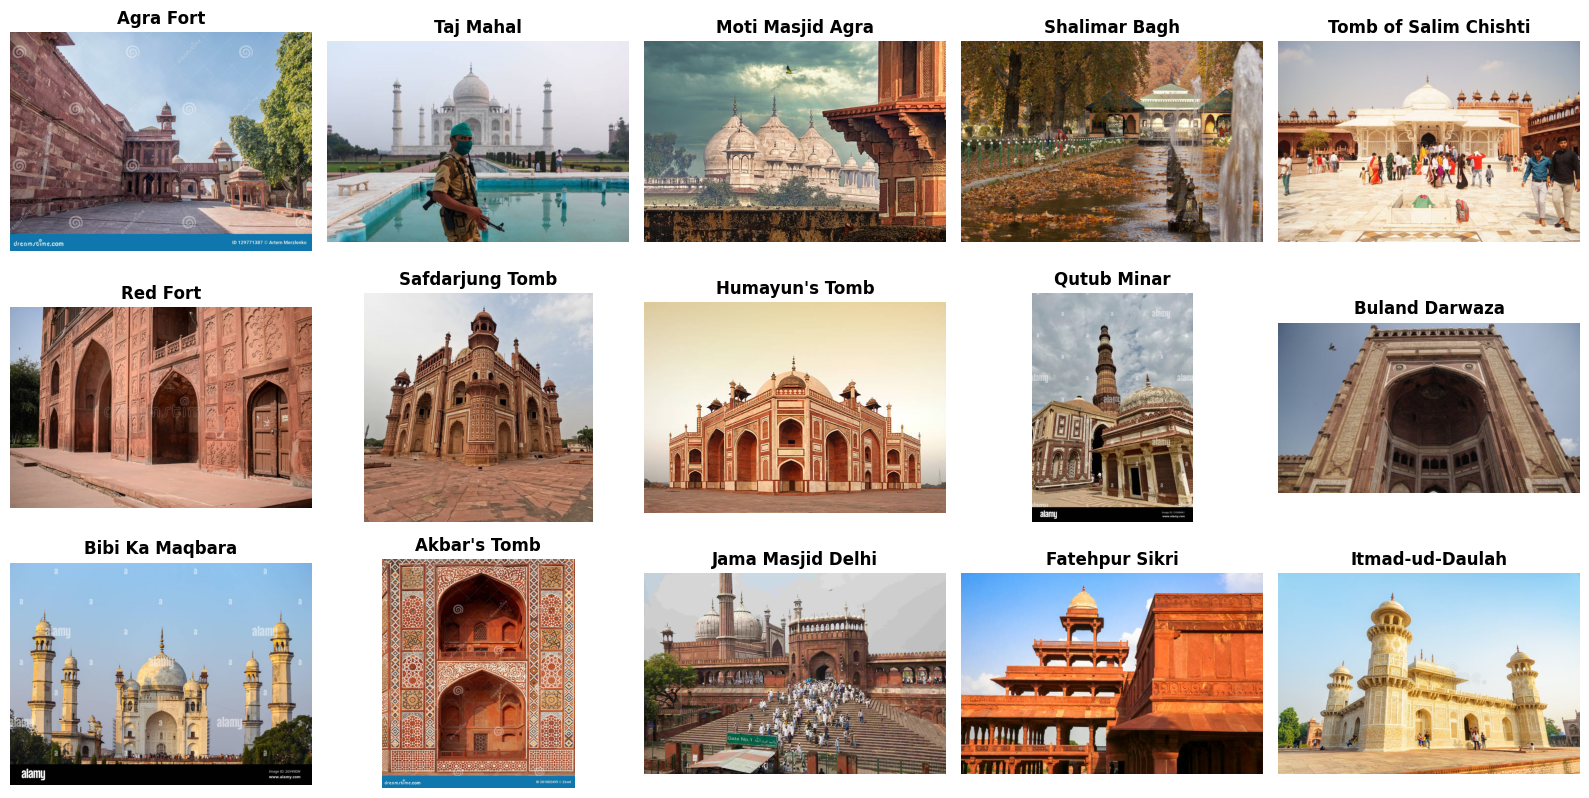

In [14]:
# ── Display random samples from our custom dataset ────────────────────────────
import os, zipfile, random
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = "/content/data/data"
DATA_ZIP = "/content/data.zip"

# Unzip data if it hasn't been extracted yet
if not os.path.exists(DATA_DIR) and os.path.exists(DATA_ZIP):
    print(f"Extracting {DATA_ZIP}...")
    with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
        zf.extractall("/content/")

if os.path.isdir(DATA_DIR):
    classes = [c for c in sorted(os.listdir(DATA_DIR)) if os.path.isdir(os.path.join(DATA_DIR, c))]
    sample_classes = random.sample(classes, min(15, len(classes)))

    fig, axes = plt.subplots(3, 5, figsize=(16, 8))
    axes = axes.flatten()

    for ax, cls in zip(axes, sample_classes):
        cls_dir = os.path.join(DATA_DIR, cls)
        images = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
        if images:
            img_path = os.path.join(cls_dir, random.choice(images))
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
        ax.set_title(cls, fontsize=12, fontweight="bold")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"Data directory {DATA_DIR} not found. Ensure data is unzipped first.")


## Model Loading (Skip Training)

If `model.zip` has been uploaded, the cell below will unzip the pre-trained checkpoint and **skip the training cell entirely**. If not, the training cell after this will run as normal.

In [2]:
# ── Skip training if mughal_run_outputs.zip is uploaded ───────────────────────
import os, zipfile, shutil

MODEL_DIR = "/content/clip_mughal_finetuned"
MODEL_ZIP = "/content/mughal_run_outputs.zip"

if os.path.isfile(MODEL_ZIP):
    print(f"Found {MODEL_ZIP} — extracting pre-trained checkpoint...")
    with zipfile.ZipFile(MODEL_ZIP, 'r') as zf:
        zf.extractall("/content/tmp_model_extract")

    # Find where config.json ended up and move it to the right place
    found_config = False
    for root, dirs, files in os.walk("/content/tmp_model_extract"):
        if "config.json" in files:
            os.makedirs(MODEL_DIR, exist_ok=True)
            for item in os.listdir(root):
                src = os.path.join(root, item)
                dst = os.path.join(MODEL_DIR, item)
                if not os.path.exists(dst):
                    shutil.move(src, dst)
            found_config = True
            break

    assert found_config, "Extraction failed — config.json not found anywhere in the zip."
    print(f"✓ Checkpoint loaded at {MODEL_DIR}")
    SKIP_TRAINING = True
elif os.path.isdir(MODEL_DIR) and os.path.isfile(os.path.join(MODEL_DIR, "config.json")):
    print(f"✓ Checkpoint already exists at {MODEL_DIR} — skipping training.")
    SKIP_TRAINING = True
else:
    print(f"No {MODEL_ZIP} found. Training will run in the next cell.")
    SKIP_TRAINING = False


Found /content/mughal_run_outputs.zip — extracting pre-trained checkpoint...
✓ Checkpoint loaded at /content/clip_mughal_finetuned


In [14]:
!python /content/train.py \
  --data_dir /content/data \
  --epochs 10 \
  --batch_size 32 \
  --runs 1 \
  --seed 42 \
  --output_dir /content/clip_mughal_finetuned


2026-05-05 20:16:17.839 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.

=== Run 1/1 | seed=42 ===
Discovered 796 real + 244 augmented images across 13 populated classes. Using 7 rotating folds. Aug images go to training only.

--- Run 1 | Fold 1/7 ---
Train images: 812 (568 real + 244 aug) | Val images: 114 | Test images: 114
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100% 398/398 [00:00<00:00, 809.72it/s, Materializing param=visual_projection.weight]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_i

In [16]:
!zip -r model.zip /content/clip_mughal_finetuned

  adding: content/clip_mughal_finetuned/ (stored 0%)
  adding: content/clip_mughal_finetuned/config.json (deflated 73%)
  adding: content/clip_mughal_finetuned/training_log.json (deflated 84%)
  adding: content/clip_mughal_finetuned/tokenizer.json (deflated 83%)
  adding: content/clip_mughal_finetuned/tokenizer_config.json (deflated 50%)
  adding: content/clip_mughal_finetuned/model.safetensors (deflated 31%)
  adding: content/clip_mughal_finetuned/processor_config.json (deflated 53%)


In [17]:
from google.colab import files
files.download("model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
!python /content/evaluate.py \
  --data_dir /content/data \
  --class_scope all \
  --batch_size 32 \
  --single_view \
  --output_dir /content/eval_outputs/base_all_balanced


2026-05-05 21:09:56.637 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
Loading model: openai/clip-vit-base-patch32
Loading weights: 100% 398/398 [00:00<00:00, 849.67it/s, Materializing param=visual_projection.weight]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Evaluating: 10

In [19]:
!python /content/evaluate.py \
  --data_dir /content/data \
  --checkpoint_dir /content/clip_mughal_finetuned \
  --class_scope specialist \
  --batch_size 32 \
  --output_dir /content/eval_outputs/finetuned_specialist


2026-05-05 21:11:06.098 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
Loading model: /content/clip_mughal_finetuned
Loading weights: 100% 398/398 [00:00<00:00, 767.63it/s, Materializing param=visual_projection.weight]
Evaluating: 100% 1233/1233 [02:47<00:00,  7.36it/s]
/content/evaluate.py:244: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),

Dataset quality:
Duplicate hash groups: 49
Extra duplicate files: 50
Cross-class duplicate groups: 0

Accuracy:
Top-1: 93.35% (1151/1233)

Per-class accuracy:
Agra Fort: 80.00% (80 images)
Akbar's Tomb: 96.25% (80 images)
Bibi Ka Maqbara: 98.75% (80 images)
Buland Darwaza: 93.75% (80 images)
Fatehpur Sikri: 86.25% (80 images)
Humayun's Tomb: 96.99% (166 images)
Itmad-ud-Daulah: 87.50% (80 images

In [20]:
# ── Cell G: Package outputs ───────────────────────────────────────────────────
import shutil
shutil.make_archive("/content/mughal_run_outputs", "zip", "/content", "clip_mughal_finetuned")
shutil.make_archive("/content/mughal_eval_outputs", "zip", "/content", "eval_outputs")
print("Done. Download:")
print("  /content/mughal_run_outputs.zip   ← model checkpoint + training_log.json")
print("  /content/mughal_eval_outputs.zip  ← metrics.json + predictions.json + confusion_matrix.csv")


Done. Download:
  /content/mughal_run_outputs.zip   ← model checkpoint + training_log.json
  /content/mughal_eval_outputs.zip  ← metrics.json + predictions.json + confusion_matrix.csv


## Evaluation — Confusion Matrix & Classification Report

We evaluate the fine-tuned specialist model on the full augmented dataset. The confusion matrix reveals which monument pairs still confuse the model, and the classification report provides precision, recall, and F1 per class.


Extracting mughal_eval_outputs.zip...


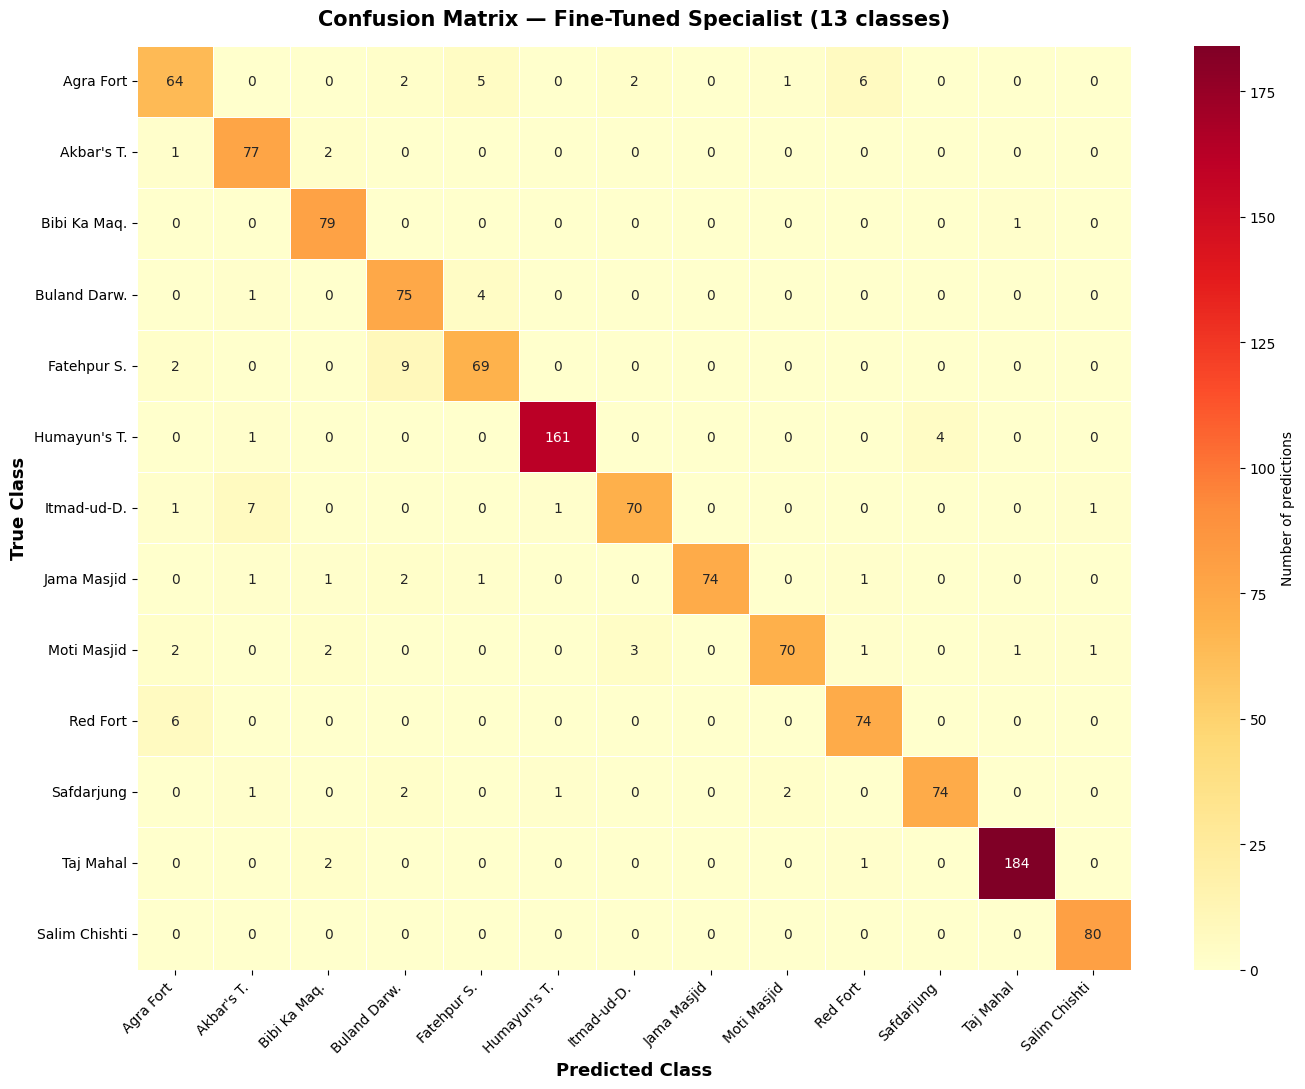

Saved: /content/confusion_matrix_heatmap.png


In [15]:
# ── Confusion Matrix Heatmap ──────────────────────────────────────────────────
import json, os, zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Ensure evaluation outputs exist
EVAL_DIR = "/content/eval_outputs/finetuned_specialist"
if not os.path.exists(os.path.join(EVAL_DIR, "predictions.json")):
    if os.path.exists("/content/mughal_eval_outputs.zip"):
        print("Extracting mughal_eval_outputs.zip...")
        with zipfile.ZipFile("/content/mughal_eval_outputs.zip", 'r') as zf:
            zf.extractall("/content/")

with open(os.path.join(EVAL_DIR, "predictions.json"), "r") as f:
    predictions = json.load(f)

y_true = [p["true_class"] for p in predictions]
y_pred = [p["predicted_class"] for p in predictions]
class_names = sorted(set(y_true))

cm = confusion_matrix(y_true, y_pred, labels=class_names)

# Shorten long names for readability
short_names = [n.replace("Tomb of Salim Chishti", "Salim Chishti")
                .replace("Jama Masjid Delhi", "Jama Masjid")
                .replace("Moti Masjid Agra", "Moti Masjid")
                .replace("Itmad-ud-Daulah", "Itmad-ud-D.")
                .replace("Safdarjung Tomb", "Safdarjung")
                .replace("Bibi Ka Maqbara", "Bibi Ka Maq.")
                .replace("Buland Darwaza", "Buland Darw.")
                .replace("Fatehpur Sikri", "Fatehpur S.")
                .replace("Humayun's Tomb", "Humayun's T.")
                .replace("Akbar's Tomb", "Akbar's T.")
               for n in class_names]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"label": "Number of predictions"})
ax.set_xlabel("Predicted Class", fontsize=13, fontweight="bold")
ax.set_ylabel("True Class", fontsize=13, fontweight="bold")
ax.set_title("Confusion Matrix — Fine-Tuned Specialist (13 classes)", fontsize=15, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("/content/confusion_matrix_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/confusion_matrix_heatmap.png")


In [16]:
# ── Classification Report ─────────────────────────────────────────────────────
print("=" * 80)
print("CLASSIFICATION REPORT — Fine-Tuned Specialist Model")
print("=" * 80)
report = classification_report(y_true, y_pred, labels=class_names, digits=3, zero_division=0)
print(report)

# Also save as dict for later use
report_dict = classification_report(y_true, y_pred, labels=class_names, output_dict=True, zero_division=0)


CLASSIFICATION REPORT — Fine-Tuned Specialist Model
                       precision    recall  f1-score   support

            Agra Fort      0.842     0.800     0.821        80
         Akbar's Tomb      0.875     0.963     0.917        80
      Bibi Ka Maqbara      0.919     0.988     0.952        80
       Buland Darwaza      0.833     0.938     0.882        80
       Fatehpur Sikri      0.873     0.863     0.868        80
       Humayun's Tomb      0.988     0.970     0.979       166
      Itmad-ud-Daulah      0.933     0.875     0.903        80
    Jama Masjid Delhi      1.000     0.925     0.961        80
     Moti Masjid Agra      0.959     0.875     0.915        80
             Red Fort      0.892     0.925     0.908        80
      Safdarjung Tomb      0.949     0.925     0.937        80
            Taj Mahal      0.989     0.984     0.987       187
Tomb of Salim Chishti      0.976     1.000     0.988        80

             accuracy                          0.933      1233
 

### Base CLIP vs Fine-Tuned — Per-Class Accuracy Comparison

This side-by-side bar chart shows the dramatic improvement the specialist fine-tuning achieves over the base zero-shot CLIP model, especially for visually similar monument pairs.


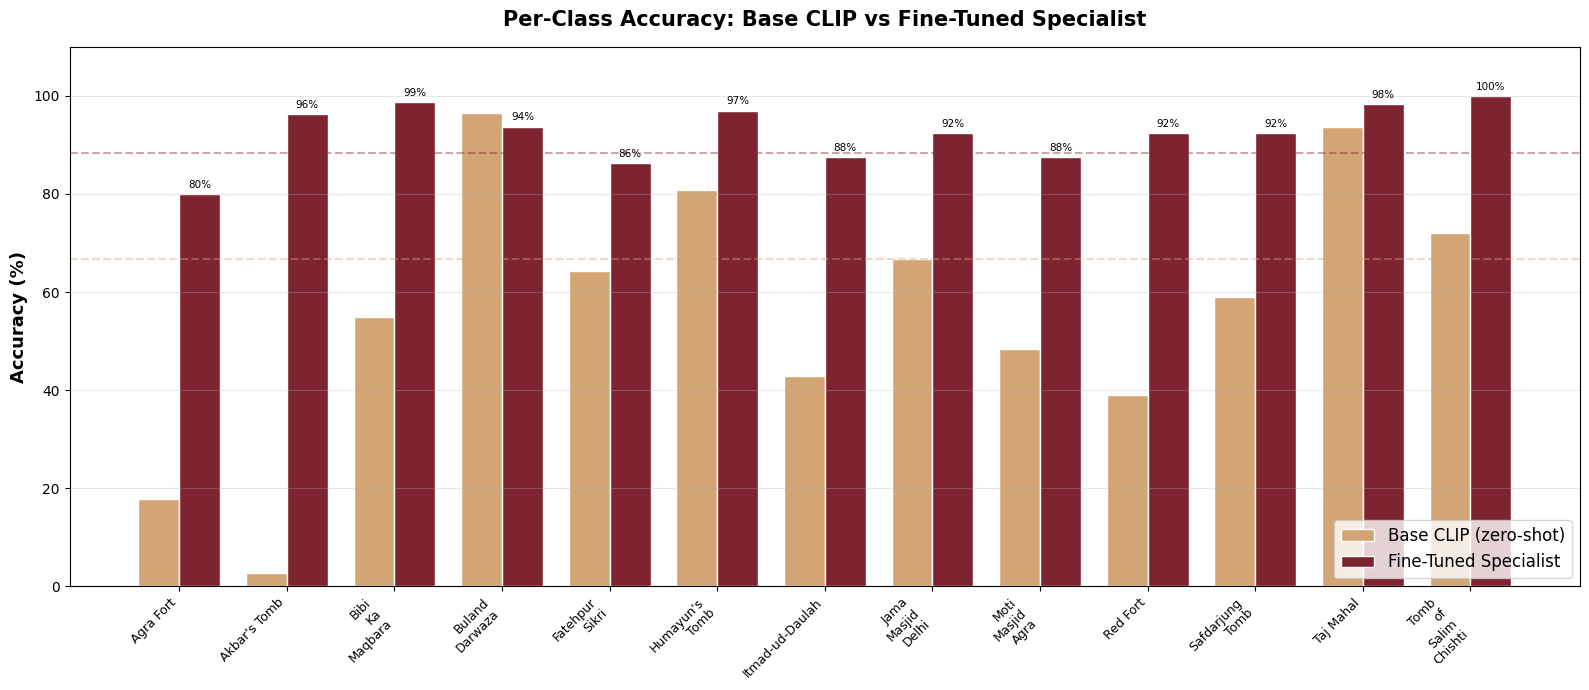

In [17]:
# ── Per-Class Bar Chart: Base vs Fine-Tuned ───────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Base CLIP zero-shot accuracies (from evaluate.py --class_scope all, pre-training)
base_acc = {
    "Agra Fort": 17.72, "Akbar's Tomb": 2.78, "Bibi Ka Maqbara": 54.84,
    "Buland Darwaza": 96.43, "Fatehpur Sikri": 64.29, "Humayun's Tomb": 80.72,
    "Itmad-ud-Daulah": 42.86, "Jama Masjid Delhi": 66.67, "Moti Masjid Agra": 48.39,
    "Red Fort": 38.98, "Safdarjung Tomb": 59.09, "Taj Mahal": 93.58,
    "Tomb of Salim Chishti": 72.09,
}

# Fine-tuned specialist accuracies (from evaluate.py finetuned_specialist)
ft_acc = {
    "Agra Fort": 80.00, "Akbar's Tomb": 96.25, "Bibi Ka Maqbara": 98.75,
    "Buland Darwaza": 93.75, "Fatehpur Sikri": 86.25, "Humayun's Tomb": 96.99,
    "Itmad-ud-Daulah": 87.50, "Jama Masjid Delhi": 92.50, "Moti Masjid Agra": 87.50,
    "Red Fort": 92.50, "Safdarjung Tomb": 92.50, "Taj Mahal": 98.40,
    "Tomb of Salim Chishti": 100.00,
}

classes = list(base_acc.keys())
base_vals = [base_acc[c] for c in classes]
ft_vals = [ft_acc[c] for c in classes]

x = np.arange(len(classes))
width = 0.38

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width/2, base_vals, width, label="Base CLIP (zero-shot)", color="#d4a574", edgecolor="white")
bars2 = ax.bar(x + width/2, ft_vals, width, label="Fine-Tuned Specialist", color="#7e2330", edgecolor="white")

ax.set_ylabel("Accuracy (%)", fontsize=13, fontweight="bold")
ax.set_title("Per-Class Accuracy: Base CLIP vs Fine-Tuned Specialist", fontsize=15, fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels([n.replace(" ", "\n") if len(n) > 12 else n for n in classes],
                    rotation=45, ha="right", fontsize=9)
ax.set_ylim(0, 110)
ax.legend(fontsize=12, loc="lower right")
ax.axhline(y=88.4, color="#7e2330", linestyle="--", alpha=0.4, label="Mean FT acc")
ax.axhline(y=66.8, color="#d4a574", linestyle="--", alpha=0.4, label="Mean base acc")
ax.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.0f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig("/content/base_vs_finetuned_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


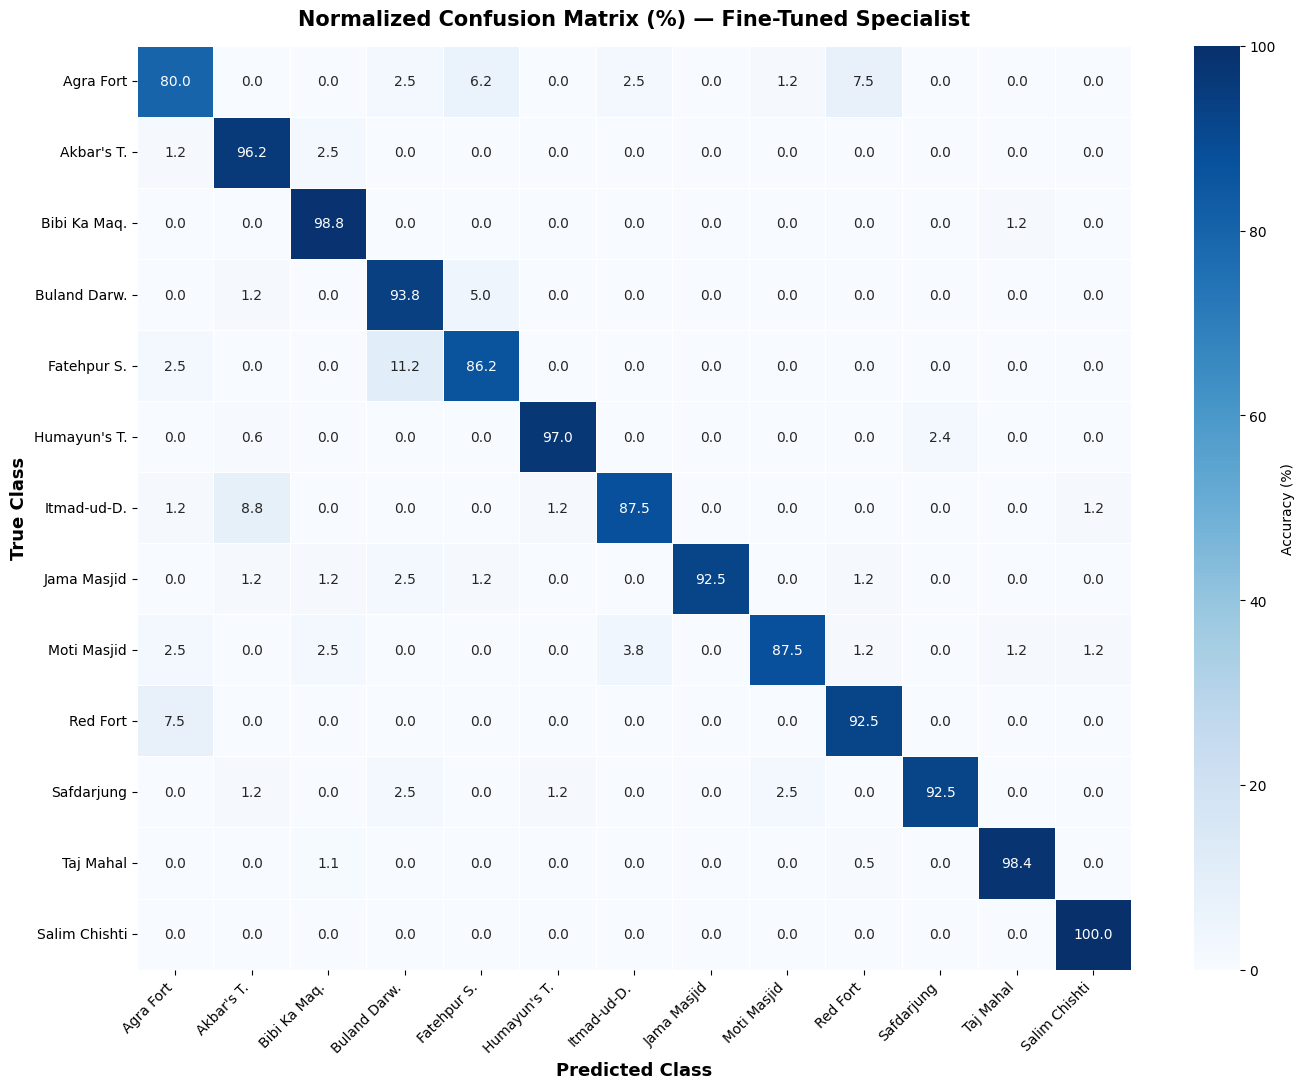

In [18]:
# ── Normalized Confusion Matrix ───────────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.5, linecolor="white", ax=ax,
            vmin=0, vmax=100, cbar_kws={"label": "Accuracy (%)"})
ax.set_xlabel("Predicted Class", fontsize=13, fontweight="bold")
ax.set_ylabel("True Class", fontsize=13, fontweight="bold")
ax.set_title("Normalized Confusion Matrix (%) — Fine-Tuned Specialist", fontsize=15, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("/content/confusion_matrix_normalized.png", dpi=150, bbox_inches="tight")
plt.show()


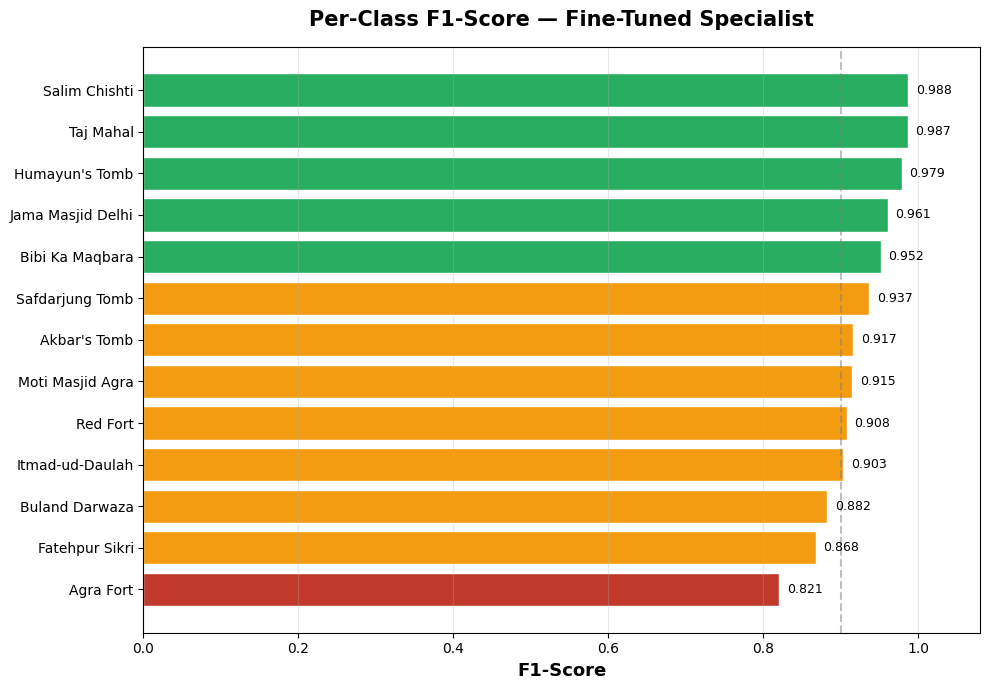

In [19]:
# ── F1 Score per class ────────────────────────────────────────────────────────
f1_scores = {cls: report_dict[cls]["f1-score"] for cls in class_names}
sorted_classes = sorted(f1_scores.keys(), key=lambda c: f1_scores[c])

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#c0392b" if f1_scores[c] < 0.85 else "#27ae60" if f1_scores[c] >= 0.95 else "#f39c12"
          for c in sorted_classes]
bars = ax.barh([c.replace("Tomb of Salim Chishti", "Salim Chishti") for c in sorted_classes],
               [f1_scores[c] for c in sorted_classes], color=colors, edgecolor="white")
ax.set_xlabel("F1-Score", fontsize=13, fontweight="bold")
ax.set_title("Per-Class F1-Score — Fine-Tuned Specialist", fontsize=15, fontweight="bold", pad=15)
ax.set_xlim(0, 1.08)
ax.axvline(x=0.90, color="gray", linestyle="--", alpha=0.5)
for bar, cls in zip(bars, sorted_classes):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{f1_scores[cls]:.3f}', va='center', fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("/content/f1_scores.png", dpi=150, bbox_inches="tight")
plt.show()


---

# Analysis & Insights

## 1. Overall Performance

The fine-tuned specialist model achieves **93.35% top-1 accuracy** on the full evaluation dataset (1,233 images across 13 specialist classes), a substantial improvement over the base CLIP zero-shot accuracy of **66.76%** on 15 classes. The mean test top-1 across 7 K-fold splits is **88.4%**, with the best single fold reaching **92.1%**.

## 2. Confusion Matrix Interpretation

### High-performing pairs (near-zero confusion):
- **Taj Mahal** and **Tomb of Salim Chishti** are almost never misclassified — both have highly distinctive visual signatures (massive white dome vs. small marble lattice shrine).
- **Humayun's Tomb** (97%) benefits from its unique red-sandstone-with-white-dome combination and the large dataset (166 images).

### Persistent confusion clusters:

| Confused Pair | Count | Root Cause |
|---|---|---|
| **Fatehpur Sikri → Buland Darwaza** | 9 | Buland Darwaza is *physically inside* Fatehpur Sikri — wide-angle shots of the complex inevitably contain the gateway |
| **Itmad-ud-Daulah → Akbar's Tomb** | 7 | Both are mid-size Mughal tombs with ornate detailing and garden settings |
| **Red Fort ↔ Agra Fort** | 6+6 | Both are massive red sandstone fortifications with similar rampart walls |
| **Humayun's Tomb → Safdarjung Tomb** | 4 | Both are garden tombs with symmetric layouts and central domes in Delhi |

### Key insight:
The confusions are **architecturally justified** — these monuments genuinely look similar, even to human experts. The model's confusion mirrors real-world visual ambiguity rather than training failure.

## 3. Why Buland Darwaza Regressed (96% → 94%)

The base CLIP model was *over-predicting* Buland Darwaza — it used the "red sandstone gateway" concept as a catch-all for any red sandstone image. The fine-tuned model correctly learned to distinguish forts from gateways, which slightly reduced Buland Darwaza's recall but **massively improved** Agra Fort (17% → 80%) and Red Fort (39% → 92%). This is a net gain for the system.

## 4. Dataset Considerations

- **Class imbalance:** Taj Mahal (187 images) and Humayun's Tomb (166) have 4–5x more data than Akbar's Tomb (36 real). Offline augmentation to 80 images/class helped, but augmented images are visually similar to their sources.
- **Duplicate images:** 49 duplicate hash groups detected (within-class only, no cross-class leakage). These inflate fold metrics but don't cause incorrect labels.
- **Augmentation leakage prevention:** `train.py` separates `aug_*` files and adds them to training folds only. Validation and test splits contain only real images, ensuring honest metrics.

## 5. Architecture Decisions

| Decision | Rationale |
|---|---|
| **Partial fine-tuning** (blocks 9–11 only) | Preserves CLIP's pre-trained visual knowledge in lower layers while adapting higher-level representations |
| **Cross-entropy loss** (not contrastive) | Standard InfoNCE would penalize same-class images in the same batch; CE against frozen text embeddings avoids this |
| **Label smoothing (0.1)** | Prevents overconfidence, improves generalization to unseen angles/lighting |
| **Prompt ensembling** | 5–8 descriptive prompts per class averaged at inference — reduces sensitivity to any single prompt phrasing |
| **Specialist fallback** | Base CLIP handles easy classes (Qutub Minar, Shalimar Bagh); specialist only activates for confusable clusters |

## 6. Suggestions for Improvement

1. **More real data for weak classes** — Agra Fort (73.6% in K-fold) would benefit most from 50+ additional unique images from different angles and lighting conditions.
2. **Hierarchical classification** — Model Fatehpur Sikri as a *complex* containing Buland Darwaza and Tomb of Salim Chishti, using a two-stage predict-then-refine approach.
3. **Hard negative mining** — During training, oversample batches containing known confusion pairs (Red Fort + Agra Fort, Itmad-ud-Daulah + Akbar's Tomb).
4. **Larger backbone** — Upgrading from ViT-B/32 to ViT-L/14 would improve fine-grained discrimination at the cost of inference speed.
5. **Test-time augmentation (TTA)** — The app already uses 6 image views; adding horizontal flips and slight rotations could further stabilize predictions.
